<div align='right'>
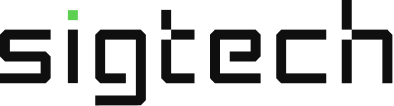
</div>

# FX Demo

- Environment
- Objects
- Building Blocks
- Example Strategies

___

## Environment

In [1]:
import datetime as dtm
import pandas as pd
import numpy as np

In [2]:
import sigtech.framework as sig

env = sig.init()
sig.env()[sig.config.CUSTOM_DATA_SOURCE_CONFIG] = [
    ("[A-Z]{6} CURNCY", "REFINITIV"),
]

SigTech environment successfully initialized


___

## Objects

There are three fundamental objects in the platform:
- **Tradable instruments**: instruments, tradable on the financial markets,
- (Tradable) **Strategies**: a set of rules and logic to buy or sell tradable instruments over time,
- **Non-tradable data**: objects that are used for signalling purposes or research like macro-economic data.
<br>

<div align='center'>
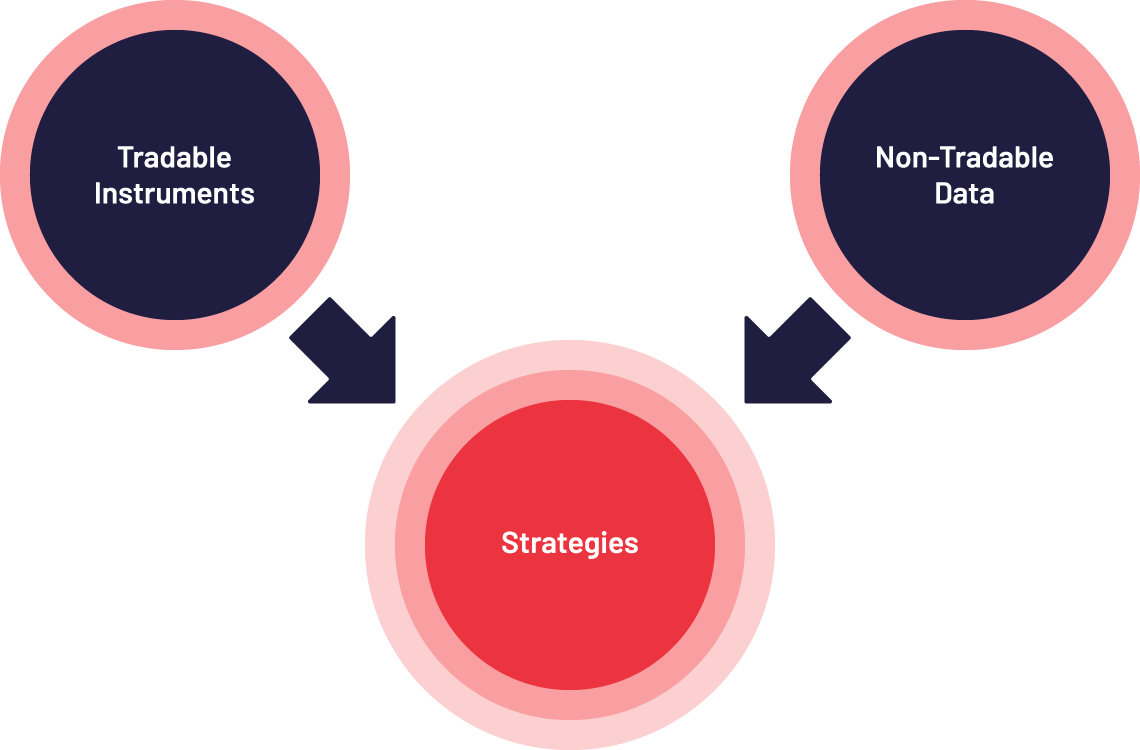
</div>


### Spot

In [18]:
pair = sig.obj.get("EURUSD CURNCY")
pair

EURUSD CURNCY <class 'sigtech.framework.instruments.fixes.FXFix'>[140222805833520]

In [19]:
pair?

Type:           FXFix
String form:    EURUSD CURNCY <class 'sigtech.framework.instruments.fixes.FXFix'>[140222805833520]
File:           /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/fixes.py
Docstring:      A class representing an FX fixing.
Init docstring: Method generated by attrs for class FXFix.

In [20]:
pair.data_dict()

{'_product_type': 'FX',
 'instrument_id': None,
 '_data_source_all': [],
 '_available_data_points': ['INTRADAY_1MIN',
  'INTRADAY_5MIN',
  'INTRADAY_10MIN',
  'INTRADAY_1HOUR',
  'EOD'],
 '_default_data_point': 'EOD',
 'price_factor': 1.0,
 'use_price_factor': True,
 'intraday_times': [],
 'intraday_tz_str': 'UTC',
 'currency': 'USD',
 'ticker': 'EURUSD',
 'db_ticker': None,
 'db_sector': 'Curncy',
 'db_history_end_date': datetime.date(9999, 12, 31),
 'fixing_sources': ['ICE TERMSTRUCTURE FXFIX GROUP',
  'CLS FXFIX GROUP',
  'QUANDL FXFIX GROUP',
  'REFINITIV FXFIX GROUP',
  'CBOE FXFIX GROUP',
  'EDI FXFIX GROUP']}

In [21]:
pair.history_fields

['OpenPrice', 'HighPrice', 'LowPrice', 'LastPrice']

In [22]:
pair.history().tail()

2023-03-21    1.07690
2023-03-22    1.07910
2023-03-23    1.08900
2023-03-24    1.07610
2023-03-27    1.07775
Name: (LastPrice, EURUSD CURNCY), dtype: float64

In [23]:
pair.intraday_history().tail()

trading_datetime
2023-03-26 20:00:00+00:00    1.07720
2023-03-26 21:00:00+00:00    1.07765
2023-03-26 22:00:00+00:00    1.07660
2023-03-26 23:00:00+00:00    1.07780
2023-03-27 00:00:00+00:00    1.07775
Name: (LastPrice, EURUSD CURNCY), dtype: float64

<AxesSubplot:>

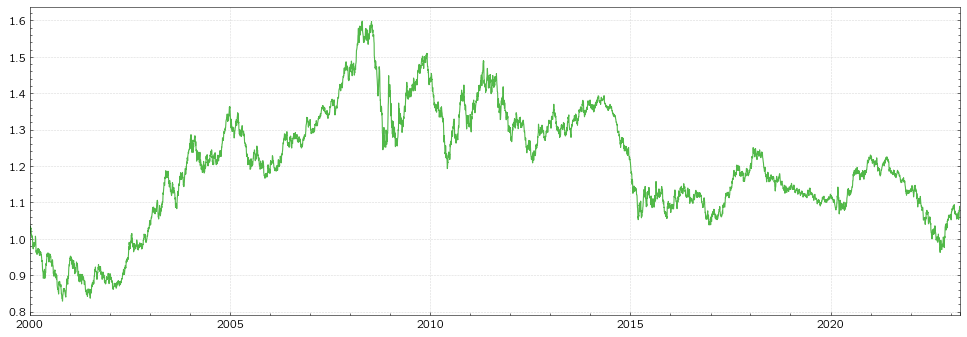

In [24]:
pair.history().plot()

### Forwards

In [25]:
sig.FXForward?

Init signature: sig.FXForward(*args, cache: bool = True, **kwargs)
Docstring:     
FXForward will pay 1.0 in the "under"-currency minus strike amount in the "over" currency at ``payment_date``.

Keyword arguments:

    * ``under``: The currency to buy, the currency which will be received at ``payment_date``
    * ``over``: The currency to sell, the currency which will be paid at ``start_date``
    * ``payment_date``: Payment date (maturity date) of FX forward
    * ``strike``: Forward strike (Optional, default=None which will use the fair strike at the valuation point)
    * ``start_date``: Trade date of the FX forward (Optional)
    * ``deliverable``: Boolean flag indicating deliverable/non-deliverable (Optional, default=True)
    * ``is_hedge``: Boolean flag indicating if hedge trade or outright trade (Optional, default=False)
    * ``forbid_settlement``: Boolean flag forcing strategies to get out of instrument prior to        settlement (Optional, default=False)

One of ``strike`` o

In [33]:
fx_forward = sig.FXForward(
    over="USD",
    under="EUR",
    start_date=dtm.date(2023, 3, 5),
    payment_date=dtm.date(2023, 6, 5),
)

In [34]:
fx_forward.strike

1.068872010248

In [35]:
fx_forward.deliverable

True

In [36]:
fx_forward.history().tail()

2023-03-21    0.012499
2023-03-22    0.014563
2023-03-23    0.024233
2023-03-24    0.011497
2023-03-27    0.013082
Name: (LastPrice, LONDON_1600, EURUSD 1.068872010248 2023-03-05:2023-06-05 DELIVERABLE NAKED FXFORWARD), dtype: float64

In [38]:
fx_forward.roll_down?

Signature:
fx_forward.roll_down(
    d: datetime.date,
    dates: Union[str, datetime.date, list],
    data_point: sigtech.framework.infra.data_adapter.common.DataPoint = None,
)
Docstring:
Compute roll-down of fx forward by moving the valuation date forward to the requested dates, keeping
spot rate and depo curves constant, i.e. depo_rate(from_original_date, for_x_number_of_days) equals
depo_rate(from_the_forward_date, for_x_number_of_days).

:param d: Valuation date.
:param dates: String/date or a list of strings/dates for which the carry/roll-down is needed.
:param data_point: Data point for the original curves.
:return: DataFrame with 1 columns ``roll_down`` - change in FXForward PV.
File:      /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/fx_otc.py
Type:      method

In [37]:
fx_forward.roll_down(dtm.date.today(), [dtm.date(2023, 4, 5), dtm.date(2023, 5, 5), dtm.date(2023, 6, 5)])

,roll_down
2023-04-05,-0.000548
2023-05-05,-0.002413
2023-06-05,-0.004320


___

## Building Blocks

Within the SigTech platform, the user has the ability to use **Building Blocks**, a set of pre-built methods designed to speed up the process of creating basic strategies.

`RollingFXForwardStrategy` is the building block that goes long the "long_currency" in rolling FX forwards and short the strategy currency (typically USD). Some keyword arguments include:
* Currencies
* Forward Tenor 
* Rolling Frequencies

In [39]:
sig.RollingFXForwardStrategy?

Init signature: sig.RollingFXForwardStrategy(*args, cache: bool = True, **kwargs)
Docstring:     
Strategy going long the "long_currency" in rolling FX forwards and short the strategy currency (typically USD).

Keyword arguments:

    * ``start_date``
    * ``end_date`` (optional, default=date.max).
    * ``currency``
    * ``long_currency``
    * ``forward_tenor`` - examples - 'ON', 'TN', 'SN', '1W', '1M', '2M', '3M', '1W-FRI', '3M_IMM', 'SOM', 'EOM',         'YEARLY'.
    * ``custom_roll_offset`` - number of days before maturity of the forward to do the roll.         (optional, default method will try to get it from ``ROLL_OFFSET`` defined in ``FXMarket`` class).
    * ``rolling_frequencies``: List of strings used to set roll dates, e.g. ['3M'] (optional). Required only to         override the logic of ``custom_roll_offset`` (which is not required in case ``rolling_frequencies`` are used).
    * ``custom_roll_dates``: Pre-specified list of roll dates (optional). All other schedule pa

In [40]:
rolling_fwd = sig.RollingFXForwardStrategy(
    long_currency="EUR",
    currency="USD",
    forward_tenor="3M_IMM",
    start_date=dtm.date(2010, 9, 14),
    rolling_frequencies=["EOM"],
)

<AxesSubplot:>

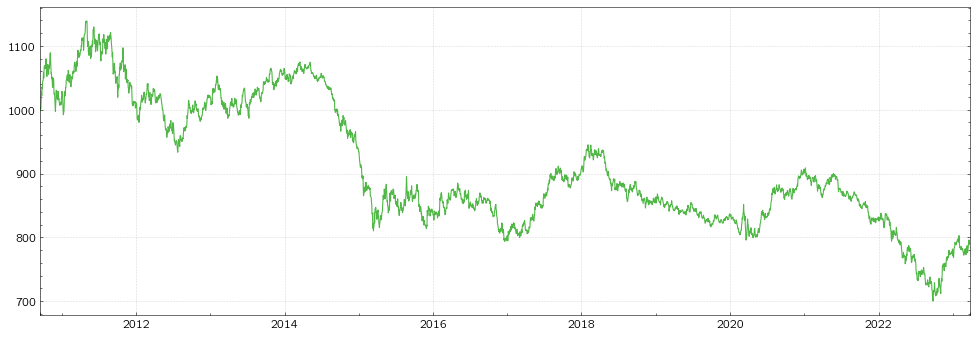

In [41]:
rolling_fwd.history().plot()

In [54]:
rolling_fwd.get_spot_delta(dtm.datetime.today())

722.6076700522403

In [58]:
rolling_fwd.history_daily_strikes?

Signature: rolling_fwd.history_daily_strikes() -> pandas.core.series.Series
Docstring:
Calculate a timeseries of the strike prices for a new forward created each day with the same currencies
and tenor as this strategy. This can be used to evaluate the strategy performance in terms of the percentage
change in this series.
File:      /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/strategies/rolling_fx_forward_strategy.py
Type:      method

In [57]:
rolling_fwd.history_daily_strikes().tail()

2023-03-21    0.923802
2023-03-22    0.922007
2023-03-23    0.913737
2023-03-24    0.924452
2023-03-27    0.923035
dtype: float64

In [43]:
rolling_fwd.plot.timeline()

In [45]:
rolling_fwd.plot.portfolio_table("TOP_ORDER_PTS", start_dt=dtm.date(2023, 1, 1), flatten=True)

In [59]:
sig.DynamicRollingFXForwardStrategy?

Init signature: sig.DynamicRollingFXForwardStrategy(*args, cache: bool = True, **kwargs)
Docstring:     
Strategy going long the "long_currency" in rolling FX forwards and short the strategy currency (typically USD) on
specified custom roll dates.

Keyword arguments:

1. start_date
2. end_date (optional, default=date.max).
3. currency
4. long_currency
5. forward_tenor - examples - '2BD', '1W', '1M', '2M', '3M', '1W-FRI', '3M_IMM', 'SOM', 'EOM', 'YEARLY'.
6. custom_roll_offset - number of days before maturity of the forward to do the roll.     (optional, default method will try to get it from ``ROLL_OFFSET`` defined in ``FXMarket`` class).

Example object creation:

::

    st = DynamicRollingFXForwardStrategy(long_currency='EUR',
                                         currency='USD',
                                         forward_tenor='3M',
                                         start_date=dtm.date(2016, 1, 14),
                                         end_date=dtm.date(2016, 7,

___

## Example Strategy: FX Carry

In [63]:
start_date = dtm.date(2013, 1, 1)

In [61]:
assets = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]

In [65]:
def create_rolling_fwd(
    asset: str,
    fwd_tenor: str = "3M_IMM",
    base_ccy: str = "USD",
    fwd_roll_offset: int = 5,
):
    return sig.RollingFXForwardStrategy(
        long_currency=asset,
        currency=base_ccy,
        forward_tenor=fwd_tenor,
        start_date=start_date,
        custom_roll_offset=fwd_roll_offset,
        ticker=f"{asset}{base_ccy} ROLLING FWD",
    )

In [77]:
fwd_universe = {asset: create_rolling_fwd(asset).name for asset in assets}

In [78]:
fwd_universe

{'AUD': 'AUDUSD ROLLING FWD STRATEGY',
 'CAD': 'CADUSD ROLLING FWD STRATEGY',
 'CHF': 'CHFUSD ROLLING FWD STRATEGY',
 'EUR': 'EURUSD ROLLING FWD STRATEGY',
 'GBP': 'GBPUSD ROLLING FWD STRATEGY',
 'JPY': 'JPYUSD ROLLING FWD STRATEGY',
 'NOK': 'NOKUSD ROLLING FWD STRATEGY',
 'NZD': 'NZDUSD ROLLING FWD STRATEGY',
 'SEK': 'SEKUSD ROLLING FWD STRATEGY'}

In [81]:
fwd_histories = pd.DataFrame({fwd: sig.obj.get(fwd).history() for fwd in fwd_universe.values()})

<AxesSubplot:>

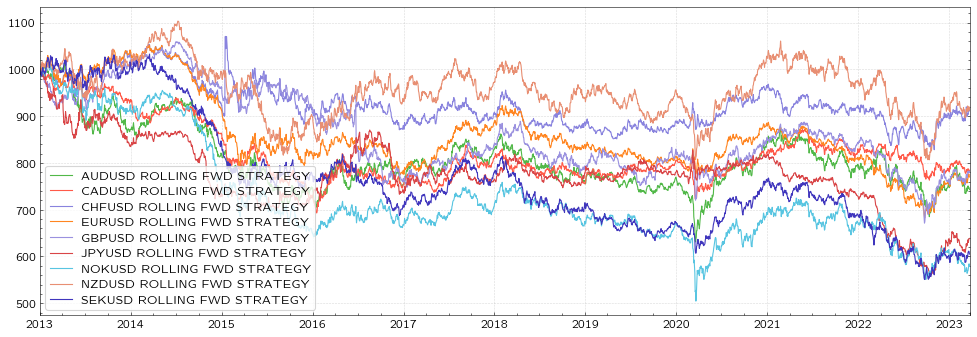

In [82]:
fwd_histories.plot()

In [83]:
fx_cross = env.fx_cross


def ccy_mapping(ccy):
    if fx_cross.is_flipped("USD", ccy):
        return f"USD{ccy} CURNCY"
    else:
        return f"{ccy}USD CURNCY"


CCY_MAPPING = {ccy: ccy_mapping(ccy) for ccy in assets}

spot_rates = {ccy: sig.obj.get(ticker).history() for ccy, ticker in CCY_MAPPING.items()}

In [84]:
def generate_fwd_rates(spot_dates, under: str, over: str, fx_market, forward_tenor: str = "3M"):
    maturities = [fx_market.fx_forward_date(over, under, date, forward_tenor) for date in spot_dates]
    return fx_market.calculate_forward_rate_batch(over, under, spot_dates, maturities)

In [85]:
fx_market = sig.FXMarket.instance()
fwd_rates = {
    ccy: pd.Series(
        generate_fwd_rates(
            spot_rates[ccy][start_date:].index,
            over=CCY_MAPPING[ccy][:3],
            under=CCY_MAPPING[ccy][3:6],
            fx_market=fx_market,
        ),
        index=spot_rates[ccy][start_date:].index,
    )
    for ccy, ticker in CCY_MAPPING.items()
}

In [86]:
signals_carry = pd.DataFrame({ccy: fwd_rates[ccy] / spot_rates[ccy] for ccy in assets}, columns=assets)
signals_carry.tail()

,AUD,CAD,CHF,EUR,GBP,JPY,NOK,NZD,SEK
2023-03-21,2.252437,0.531005,1.183552,0.857835,0.671031,0.000058,0.009007,2.627605,0.009383
2023-03-22,2.229929,0.531827,1.183704,0.854423,0.667296,0.000058,0.009131,2.585772,0.009377
2023-03-23,2.208255,0.536846,1.207038,0.839061,0.657629,0.000059,0.009482,2.533917,0.009545
2023-03-24,2.259125,0.528666,1.197760,0.859076,0.668147,0.000059,0.009110,2.596096,0.009232
2023-03-27,2.250639,0.531250,1.195692,0.856446,0.665792,0.000059,0.009166,2.592655,0.009278


In [168]:
fx_carry = sig.SignalStrategy(
    start_date=start_date,
    currency="USD",
    signal_name=sig.signal_library.from_ts(signals_carry).name,
    rebalance_frequency="EOM",
    allocation_function=sig.signal_library.allocation.long_short_dollar_neutral,
    allocation_kwargs={"proportion": 0.5},
    instrument_mapping=fwd_universe,
    ticker="FX CARRY",
)

<AxesSubplot:>

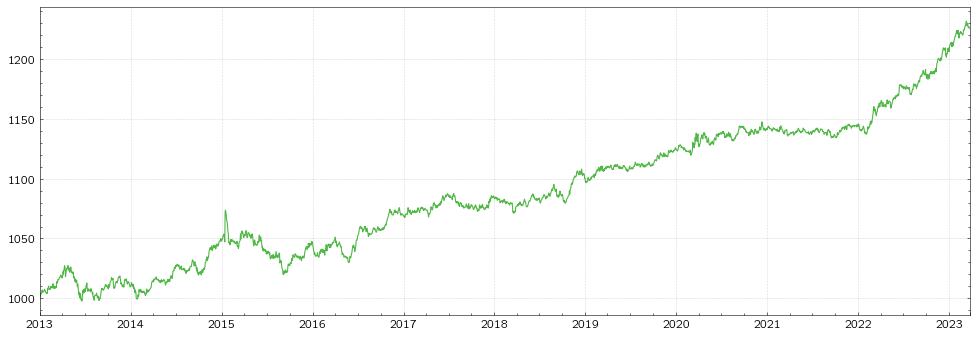

In [169]:
fx_carry.history().plot()

In [170]:
fx_carry.plot.timeline()

___

## Example Strategy: FX Spot Intraday

In [98]:
fx_spot_universe = ["EURUSD CURNCY", "GBPUSD CURNCY", "USDJPY CURNCY"]

In [114]:
def calculate_signals(fx_pair, short_span, long_span, entry_time, exit_time) -> pd.Series:
    # Fetch Instrument
    imnt = sig.obj.get(fx_pair)

    # Moving Average Crossover Signal
    signal_df = np.sign(imnt.history().rolling(short_span).mean() - imnt.history().rolling(long_span).mean()).dropna()

    # Replace 0's with NaN
    signal_df = signal_df.replace(0, np.nan)

    # Shift for alternating values only (i.e. when crossover occurs)
    signal_df = signal_df[signal_df != signal_df.shift()]

    # Add 1 day to trade at next day open/close
    signal_df.index = signal_df.index + dtm.timedelta(days=1)

    # Map trade entry to exchange open + x minutes
    entry_df = signal_df.to_frame()
    entry_df.index = entry_df.index + dtm.timedelta(hours=entry_time)
    entry_df.columns = [imnt.name]

    # Map trade exit to exchange close - y minutes
    exit_df = pd.DataFrame({"Signal": 0}, index=signal_df.index)
    exit_df.index = exit_df.index + dtm.timedelta(hours=exit_time)
    exit_df.columns = [imnt.name]

    return pd.concat([entry_df, exit_df]).sort_index()

In [234]:
signals = {}

signals = [
    calculate_signals(
        fx_pair=x,
        short_span=5,
        long_span=20,
        entry_time=9,
        exit_time=17,
    )
    for x in fx_spot_universe
]

# Concatenate and take intersection of dates
full_signal = pd.concat(signals, join="outer", axis=1).sort_index()
full_signal

,EURUSD CURNCY,GBPUSD CURNCY,USDJPY CURNCY
2000-01-29 09:00:00,-1.0,-1.0,1.0
2000-01-29 17:00:00,0.0,0.0,0.0
2000-02-22 09:00:00,1.0,NaN,NaN
2000-02-22 17:00:00,0.0,NaN,NaN
2000-02-26 09:00:00,NaN,1.0,NaN
...,...,...,...
2023-02-07 17:00:00,NaN,0.0,0.0
2023-02-08 09:00:00,-1.0,NaN,NaN
2023-02-08 17:00:00,0.0,NaN,NaN
2023-03-15 09:00:00,1.0,1.0,-1.0


In [235]:
intraday_strategy = sig.IntradaySignalStrategy(
    currency="USD",
    start_date=dtm.date(2012, 1, 4),
    signal_name=sig.signal_library.from_ts(full_signal).name,
    execution_delay="1m",
    convert_long_short_weight=False,
    total_return=False,
    ticker="Intraday Momentum",
)

<AxesSubplot:>

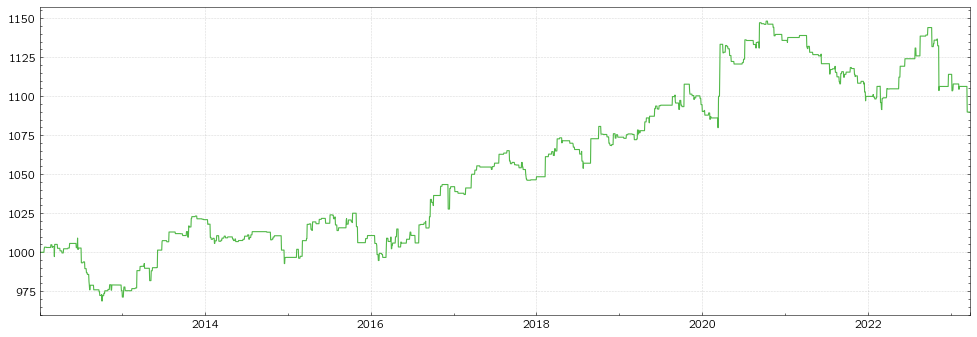

In [236]:
intraday_strategy.history().plot()

___

## Optimization

In [237]:
combined_strategy_df = pd.DataFrame(
    {
        fx_carry.name: fx_carry.history(),
        intraday_strategy.name: intraday_strategy.history(),
    }
)
returns_df = combined_strategy_df.pct_change().dropna()

In [238]:
sig.Optimizer?

Init signature:
sig.Optimizer(
    factor_exposures: Optional[sigtech.framework.analytics.optimization.factor_exposure.FactorExposures] = None,
    optimization_problem: Optional[sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem] = None,
    factor_exposure_kwargs: Optional[dict] = None,
    cvx_kwargs: Optional[dict] = None,
    scipy_kwargs: Optional[dict] = None,
)
Docstring:     
A class implementing an optimisation task.

To run an optimisation problem, a ``OptimizationProblem`` object needs to be provided.

If fit requires Factors then the ``FactorExposures`` containing the data must also be passed and the weights are     found with ``Optimizer.calculate_optimized_weights``.
Otherwise, if the optimization does not require knowledge of factors, ``FactorExposures=None`` is valid but     ``calculate_optimized_weights_with_fit`` must be used.

.. seealso:: `sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem`

An example o

In [239]:
opt = sig.PortfolioOptimizer()
opt.prefer_mean_variance().calculate_weights(returns_df)

FX CARRY STRATEGY                 19.252562
INTRADAY MOMENTUM V33 STRATEGY     7.146855
dtype: float64

In [240]:
opt.require_equal_risk_contribution().require_fully_invested().calculate_weights(returns_df)

FX CARRY STRATEGY                 0.544808
INTRADAY MOMENTUM V33 STRATEGY    0.455192
dtype: float64

In [241]:
po = sig.PortfolioOptimizer().prefer_inverse_vol_weighting().require_long_only().require_fully_invested()

optimized_strategy_inverse_vol = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    rebalance_frequency="EOM",
    signal_name=sig.signal_library.from_ts(combined_strategy_df).name,
    allocation_function=sig.signal_library.allocation.optimized_allocations,
    allocation_kwargs={
        "periods": 252,
        "optimization_frequency": "EOM",
        **po.signal_strategy_allocation_kwargs(),
    },
    ticker="Inverse Volatility Basket",
)

Optimizations:   0%|          | 0/134 [00:00<?, ?it/s]

<AxesSubplot:>

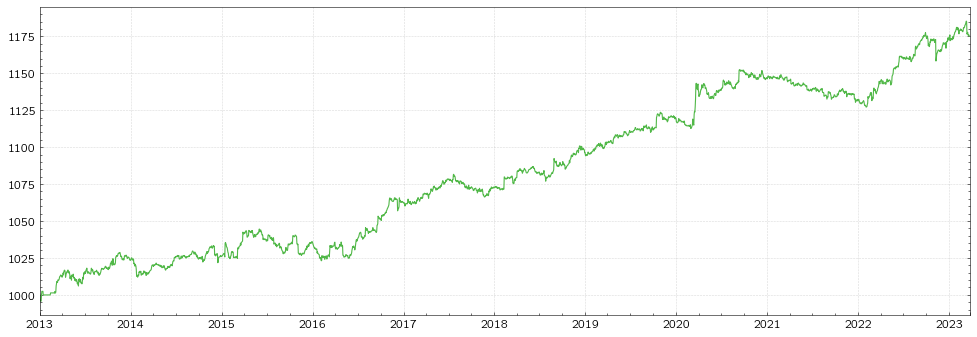

In [242]:
optimized_strategy_inverse_vol.history().plot()

In [243]:
optimized_strategy_inverse_vol.plot.portfolio_table()

___

## Performance and Analytics

,FX CARRY STRATEGY,INTRADAY MOMENTUM V33 STRATEGY,INVERSE VOLATILITY BASKET V3 STRATEGY
Annualised Excess Return,2.01%,0.77%,1.59%
Annualised Standard Deviation,2.23%,2.64%,1.71%
Annualised Sharpe Ratio (vs Cash),0.872,0.294,0.898
Annualised Sortino Ratio (vs Cash),1.561,0.451,1.513
Max Drawdown,-5.03%,-5.08%,-2.20%
Kurtosis,32.657,50.853,18.120
Skewness,1.720,0.478,0.260
Mean Positive Return,0.10%,0.31%,0.07%
Mean Negative Return,-0.10%,-0.30%,-0.07%
Proportion Positive Returns,52.40%,7.21%,52.44%


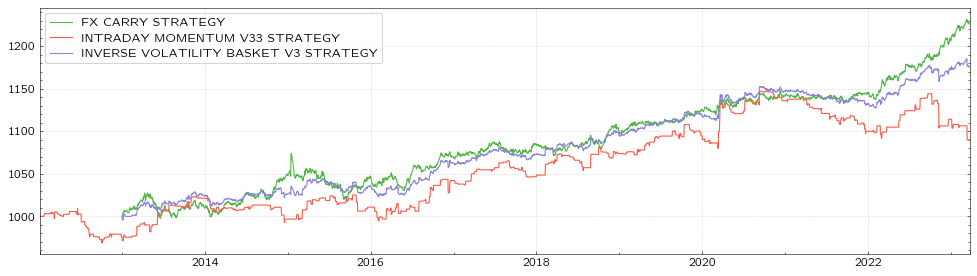

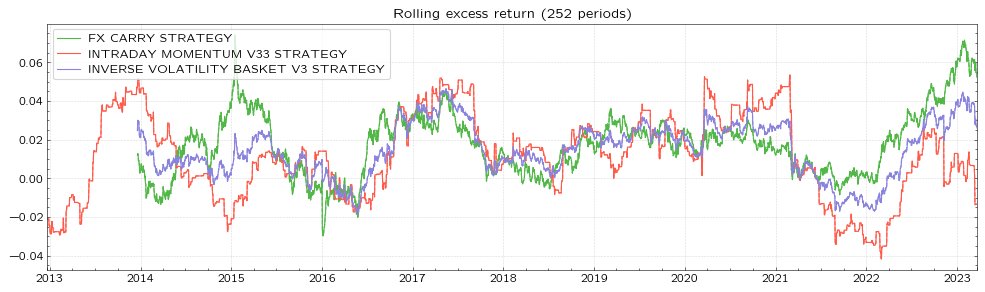

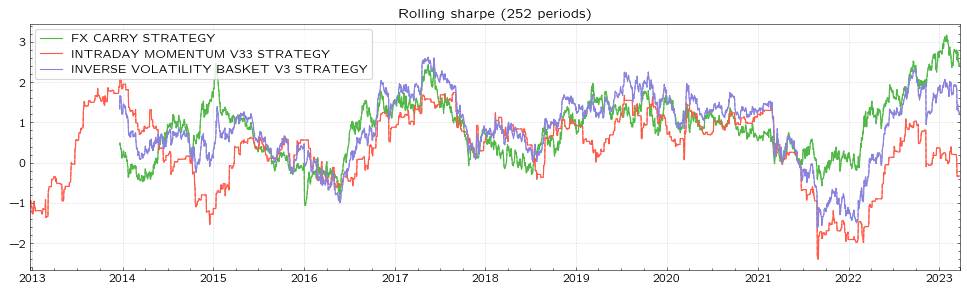

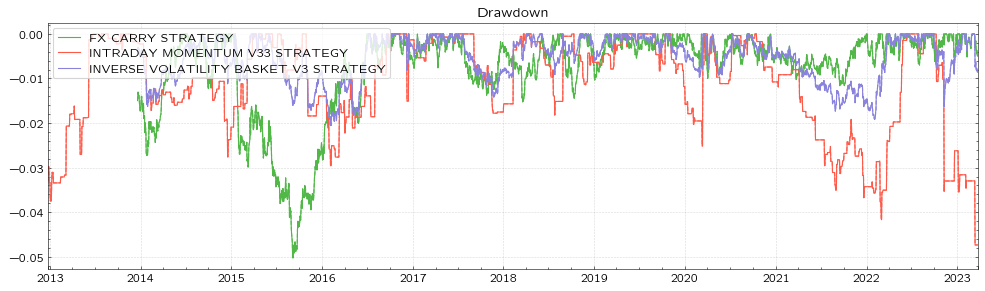

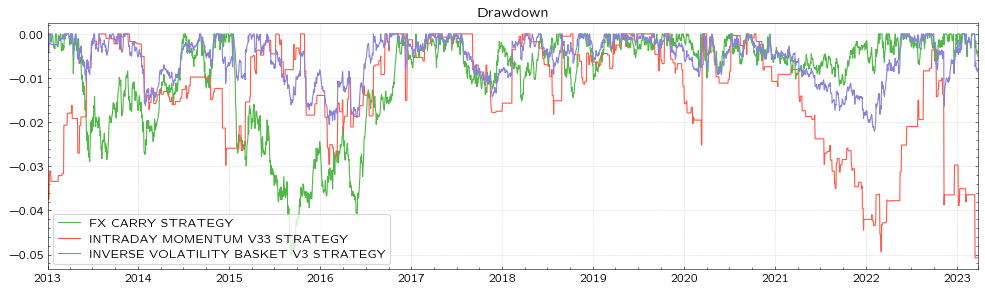

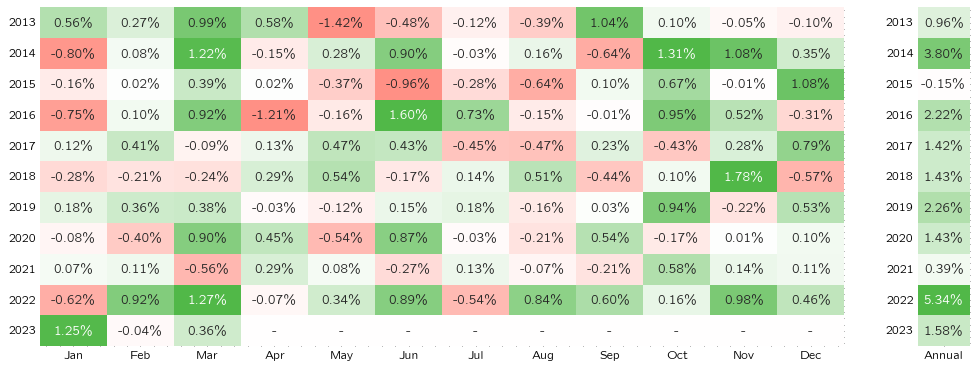

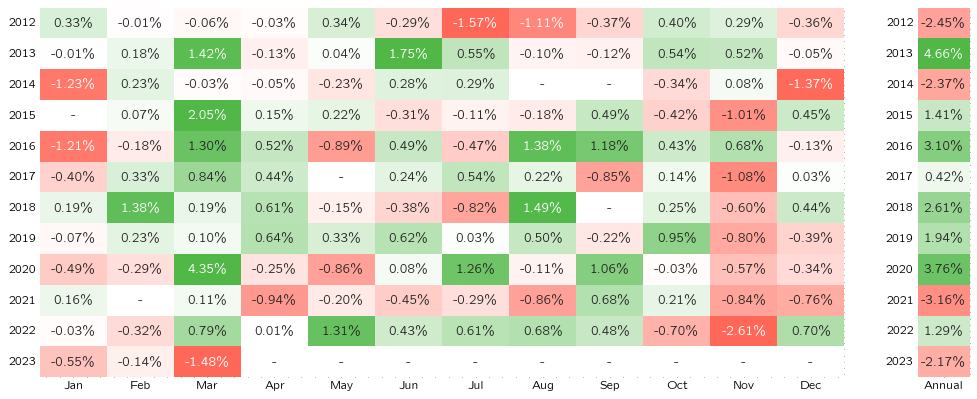

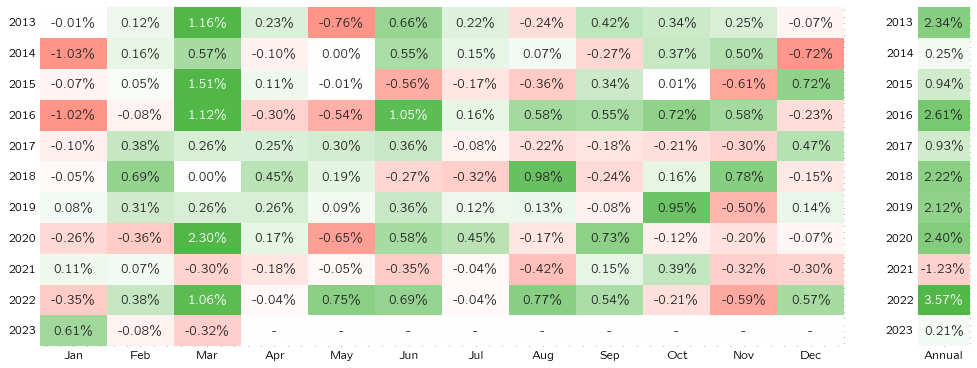

In [244]:
sig.PerformanceReport([fx_carry, intraday_strategy, optimized_strategy_inverse_vol]).report()